In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
%matplotlib inline
plt.style.use('ggplot')  # 更改绘图风格
plt.rcParams['font.sans-serif'] = ['SimHei']

Text(0.5, 1.0, '每月的消费人数')

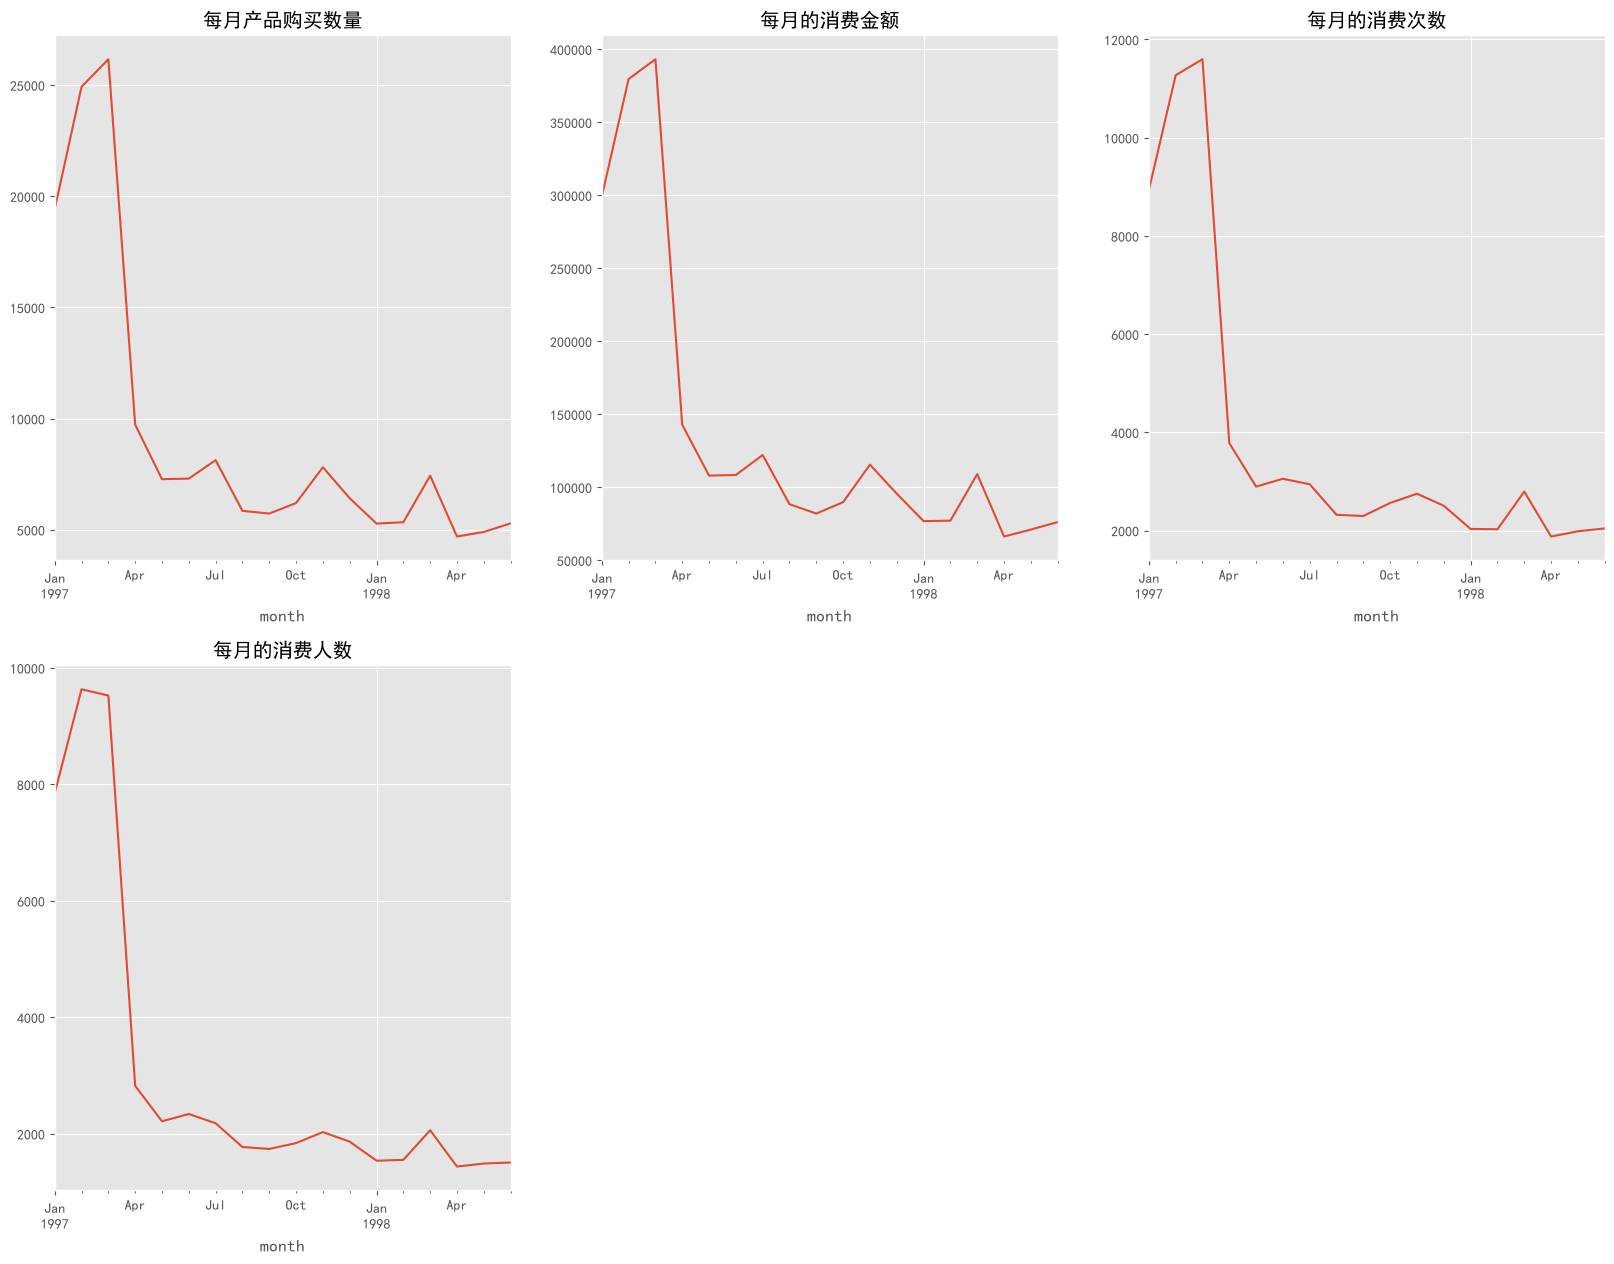

In [10]:
# 导入数据
columns = ['user_id', 'order_dt', 'order_products', 'order_amount']
# sep=r'\s+'：匹配任意空格字符
df = pd.read_csv('../data/ecommerce_transactions.txt', header=None, names=columns, sep=r'\s+')
# 处理日期格式（order_dt）
df['order_date'] = pd.to_datetime(df['order_dt'],
                                  format='%Y%m%d')  # %Y：4位数年份1949 %y：两位数年份49 %m：两位数月份 %d：两位数月份 %h：两位数小时 %M：两位数分钟 %s：两位数秒
'''
df ['month'] 字段说明
用途：按月聚合分组的标记字段
输入源：order_date（datetime 日期列）
运算链路：datetime 日期 → 月度周期 Period → 转回 datetime（当月第一天）
输出类型：datetime64 [us]，可正常使用.dt、groupby、绘图筛选
等价简写：df ['month'] = df ['order_date'].dt.floor ('MS')
'''
df['month'] = df['order_date'].dt.to_period('M').dt.to_timestamp()
# 按照月份分析每个用户的消费金额，次数，消费人数
plt.figure(figsize=(20, 15))  # 单位：英寸
plt.subplot(2, 3, 1)
df.groupby(by='month')['order_products'].sum().plot()
plt.title('每月产品购买数量')
plt.subplot(2, 3, 2)
df.groupby(by='month')['order_amount'].sum().plot()
plt.title('每月的消费金额')
plt.subplot(2, 3, 3)
df.groupby(by='month')['user_id'].count().plot()
plt.title('每月的消费次数')
plt.subplot(2, 3, 4)
df.groupby(by='month')['user_id'].nunique().plot()
plt.title('每月的消费人数')

In [11]:
# 用户个体消费分析
# 1.用户角度：共计23570个用户，均购买商品数量为7，但50中位数只有3，最大购买量为1033，均值大于中位数（右态分布）
user_grouped = df.groupby(by='user_id')[['order_dt', 'order_products', 'order_amount']].sum()
print(user_grouped.describe())

           order_dt  order_products  order_amount
count  2.357000e+04    23570.000000  23570.000000
mean   5.902627e+07        7.122656    106.080426
std    9.460684e+07       16.983531    240.925195
min    1.997010e+07        1.000000      0.000000
25%    1.997021e+07        1.000000     19.970000
50%    1.997032e+07        3.000000     43.395000
75%    5.992125e+07        7.000000    106.475000
max    4.334408e+09     1033.000000  13990.930000


<Axes: xlabel='order_products', ylabel='order_amount'>

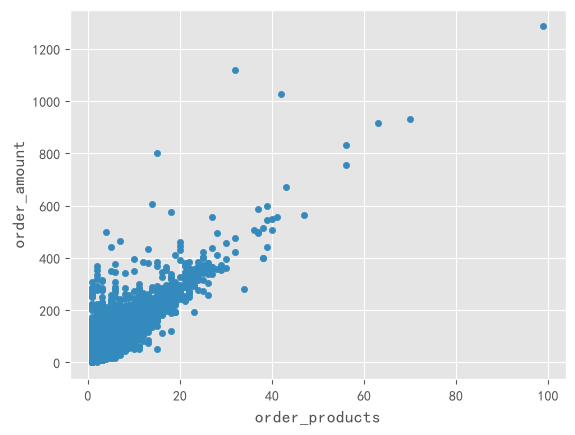

In [12]:
df.plot(kind = 'scatter', x = 'order_products', y = 'order_amount')

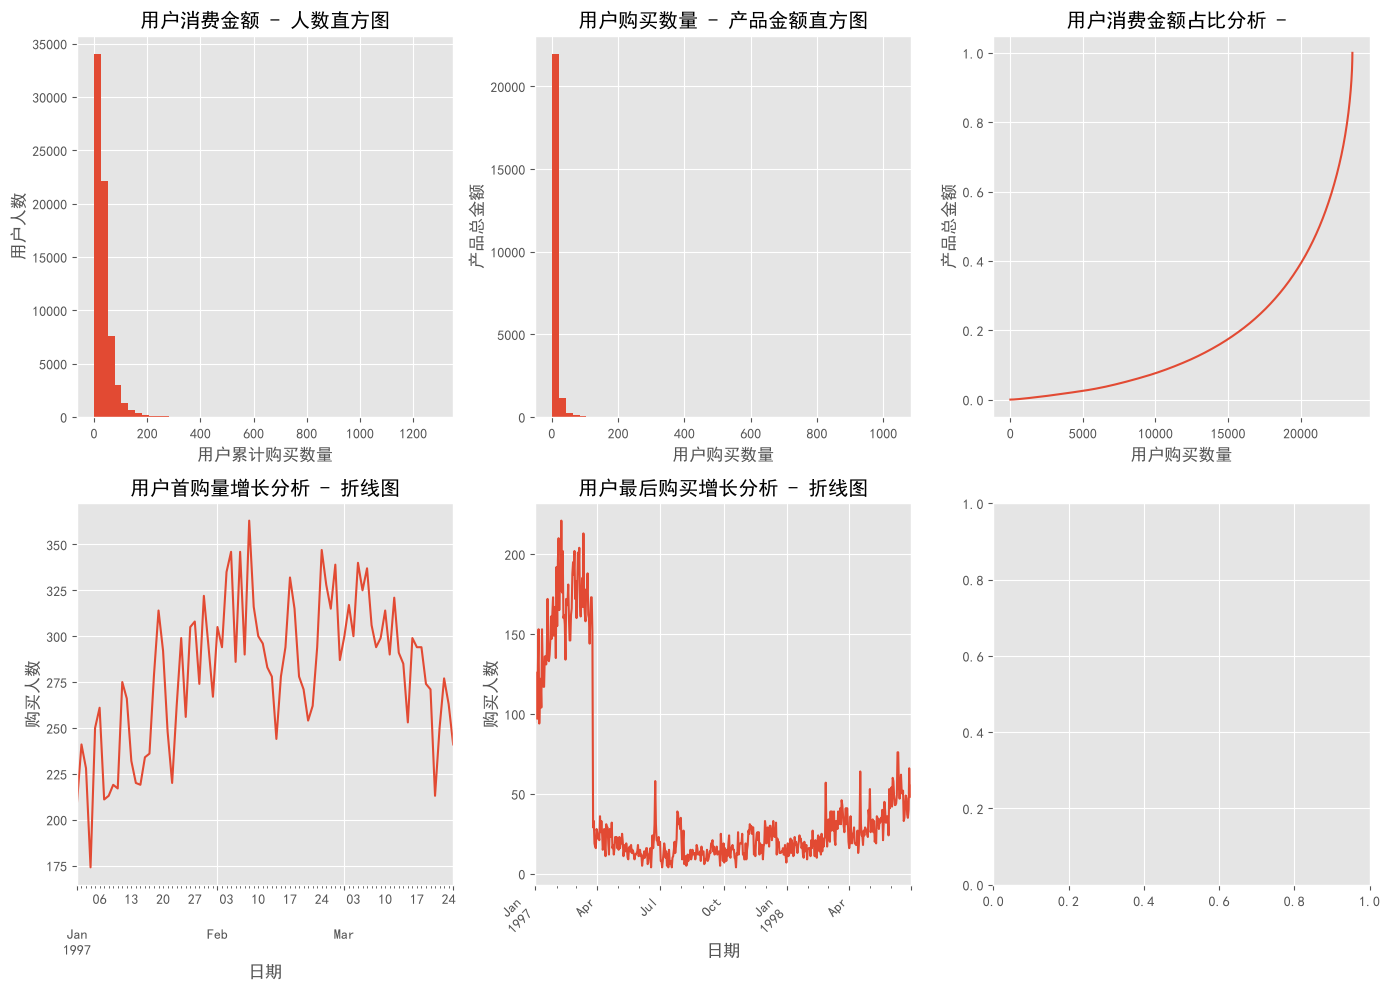

,user_id,order_amount,amount_cum_sum,prop
23565,7931,6497.18,2463822.60,0.985405
23566,19339,6552.70,2470375.30,0.988025
23567,7983,6973.07,2477348.37,0.990814
23568,14048,8976.33,2486324.70,0.994404
23569,7592,13990.93,2500315.63,1.000000


In [26]:
# 定义画布
fig, axes = plt.subplots(2, 3, figsize=(14, 10))
# 图1
ax = axes[0, 0]
df['order_amount'].plot(kind='hist', ax=ax, bins=50)
ax.set_xlabel('用户累计购买数量')
ax.set_ylabel('用户人数')
ax.set_title('用户消费金额 - 人数直方图')
# 图2
ax = axes[0, 1]
df.groupby(by=['user_id'])['order_products'].sum().plot(kind='hist', ax=ax, bins=50)
ax.set_xlabel('用户购买数量')
ax.set_ylabel('产品总金额')
ax.set_title('用户购买数量 - 产品金额直方图')
# 图3
ax = axes[0, 2]
user_cum_sum = df.groupby(by=['user_id'])['order_amount'].sum().sort_values(ascending=True).reset_index()
user_cum_sum['amount_cum_sum'] = user_cum_sum['order_amount'].cumsum()
amount_total = user_cum_sum['amount_cum_sum'].max()
user_cum_sum['prop'] = user_cum_sum.apply(lambda x: x['amount_cum_sum'] / amount_total, axis=1)
user_cum_sum['prop'].plot(ax=ax)
ax.set_xlabel('用户购买数量')
ax.set_ylabel('产品总金额')
ax.set_title('用户消费金额占比分析 - ')
ax = axes[1, 0]
# 图4用户首购时间
first_series = df.groupby(by='user_id')['order_date'].min()
daily_new_user = first_series.value_counts().sort_index()
daily_new_user.plot(ax=ax)
ax.set_xlabel('日期')
ax.set_ylabel('购买人数')
ax.set_title('用户首购量增长分析 - 折线图')
# 图5用户首购时间
ax = axes[1, 1]
last_series = df.groupby(by='user_id')['order_date'].max()
daily_old_user = last_series.value_counts().sort_index()
daily_old_user.plot(ax=ax)
ax.set_xlabel('日期')
ax.set_ylabel('购买人数')
ax.set_title('用户最后购买增长分析 - 折线图')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()
plt.close()

In [32]:
rfm = df.pivot_table(index='user_id',
                     values=['order_products', 'order_amount', 'order_date'],
                     aggfunc={
                         'order_products': 'sum',  # 购买产品的总数量
                         'order_date': 'max',  # 最后一次购买时间
                         'order_amount': 'sum',  # 消费总金额
                     })
rfm['R'] = -(rfm['order_date'] - rfm['order_date'].max()) / np.timedelta64(1, 'D')  # 取相差的天数保留一位小数
rfm.rename(columns={'order_products': 'F', 'order_amount': 'M'},inplace=True)
rfm.head()

,M,order_date,F,R
user_id,,,,
1,11.77,1997-01-01,1,545.0
2,89.00,1997-01-12,6,534.0
3,156.46,1998-05-28,16,33.0
4,100.50,1997-12-12,7,200.0
5,385.61,1998-01-03,29,178.0


In [ ]:
# RFM计算方式：每一列的数据 - 数据所在列的平均值